In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('fake_job_postings.csv')

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.shape

(17880, 18)

In [5]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [6]:
df=df.drop(['job_id','salary_range','department'],axis=1)

In [7]:
text_cols = ['company_profile', 'description', 'requirements', 'benefits', 'title', 'location']
df[text_cols] = df[text_cols].fillna('')

In [8]:
df.isnull().sum()

title                     0
location                  0
company_profile           0
description               0
requirements              0
benefits                  0
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        3471
required_experience    7050
required_education     8105
industry               4903
function               6455
fraudulent                0
dtype: int64

In [9]:
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [10]:
df.isnull().sum()

title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [11]:
df['combined_text'] = df['title'] + ' ' + df['company_profile'] + ' ' + df['description'] + ' ' + df['requirements'] + ' ' + df['benefits']

In [12]:
df['combined_text'].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: combined_text, dtype: object

In [13]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

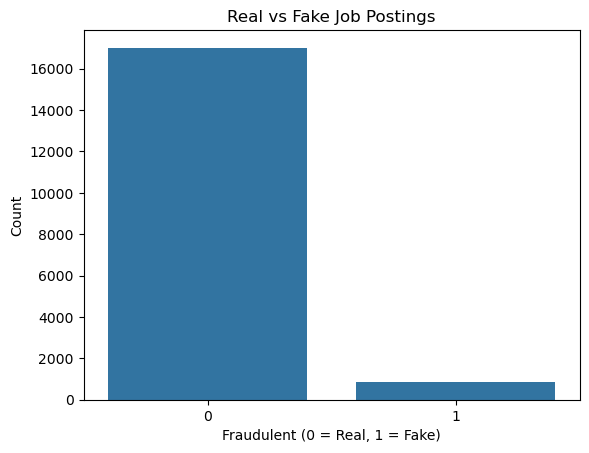

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent', data=df)
plt.title('Real vs Fake Job Postings')
plt.xlabel('Fraudulent (0 = Real, 1 = Fake)')
plt.ylabel('Count')
plt.show()

In [15]:
pd.crosstab(df['has_company_logo'], df['fraudulent'], normalize='index') * 100

fraudulent,0,1
has_company_logo,,
0,84.071038,15.928962
1,98.009845,1.990155


In [16]:
pd.crosstab(df['telecommuting'], df['fraudulent'], normalize='index') * 100

fraudulent,0,1
telecommuting,,
0,95.313504,4.686496
1,91.655802,8.344198


In [17]:
!pip install wordcloud


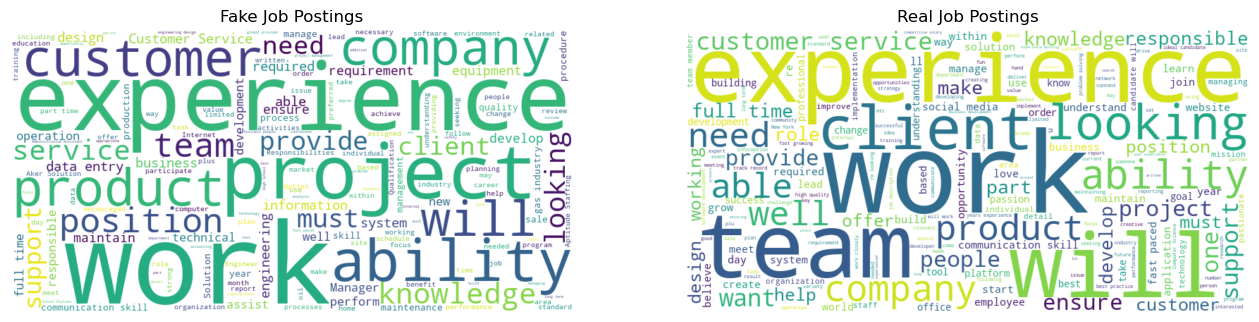

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(df[df['fraudulent'] == 1]['combined_text'])
real_text = ' '.join(df[df['fraudulent'] == 0]['combined_text'])

fake_wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
real_wc = WordCloud(width=800, height=400, background_color='white').generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(fake_wc, interpolation='bilinear')
axes[0].set_title('Fake Job Postings')
axes[0].axis('off')

axes[1].imshow(real_wc, interpolation='bilinear')
axes[1].set_title('Real Job Postings')
axes[1].axis('off')

plt.show()

In [19]:
df['text_length'] = df['combined_text'].apply(len)
df.groupby('fraudulent')['text_length'].mean()

fraudulent
0    2700.587575
1    2078.638568
Name: text_length, dtype: float64

In [20]:
pd.crosstab(df['employment_type'], df['fraudulent'], normalize='index') * 100


fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876
Unknown,93.056756,6.943244


In [21]:
import sqlite3

conn = sqlite3.connect('job_postings.db')
df.to_sql('postings', conn, if_exists='replace', index=False)

17880

In [22]:
query1 = """
SELECT industry, 
       COUNT(*) as total_postings,
       SUM(fraudulent) as fake_count,
       ROUND(SUM(fraudulent) * 100.0 / COUNT(*), 2) as fake_percentage
FROM postings
GROUP BY industry
ORDER BY fake_percentage DESC
LIMIT 10
"""
pd.read_sql(query1, conn)

,industry,total_postings,fake_count,fake_percentage
0,Ranching,1,1,100.00
1,Military,2,1,50.00
2,Animation,5,2,40.00
3,Oil & Energy,287,109,37.98
4,Accounting,159,57,35.85
5,"Leisure, Travel & Tourism",76,21,27.63
6,Computer Networking,44,12,27.27
7,Executive Office,8,2,25.00
8,Defense & Space,9,2,22.22
9,Investment Management,6,1,16.67


In [23]:
query2 = """
SELECT employment_type,
       COUNT(*) as total_postings,
       SUM(fraudulent) as fake_count,
       ROUND(SUM(fraudulent) * 100.0 / COUNT(*), 2) as fake_percentage
FROM postings
GROUP BY employment_type
ORDER BY fake_percentage DESC
"""
pd.read_sql(query2, conn)

,employment_type,total_postings,fake_count,fake_percentage
0,Part-time,797,74,9.28
1,Unknown,3471,241,6.94
2,Other,227,15,6.61
3,Full-time,11620,490,4.22
4,Contract,1524,44,2.89
5,Temporary,241,2,0.83


In [24]:
query3 = """
SELECT fraudulent,
       AVG(text_length) as avg_text_length,
       COUNT(*) as total_postings
FROM postings
GROUP BY fraudulent
"""
pd.read_sql(query3, conn)

,fraudulent,avg_text_length,total_postings
0,0,2700.587575,17014
1,1,2078.638568,866


In [25]:
query4 = """
SELECT has_company_logo,
       COUNT(*) as total_postings,
       SUM(fraudulent) as fake_count,
       ROUND(SUM(fraudulent) * 100.0 / COUNT(*), 2) as fake_percentage
FROM postings
GROUP BY has_company_logo
"""
pd.read_sql(query4, conn)

,has_company_logo,total_postings,fake_count,fake_percentage
0,0,3660,583,15.93
1,1,14220,283,1.99


In [26]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rinsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          
    text = re.sub(r'[^a-z\s]', ' ', text)        
    text = re.sub(r'\s+', ' ', text).strip()     
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [28]:
df['cleaned_text'] = df['combined_text'].apply(clean_text)

In [29]:
df[['combined_text', 'cleaned_text']].head()

,combined_text,cleaned_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc g...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['cleaned_text'])

In [31]:
X_text.shape

(17880, 5000)

In [32]:
tfidf.get_feature_names_out()[:20]

array(['aa', 'aabbf', 'aan', 'ab', 'abc', 'abilities', 'ability', 'able',
       'abreast', 'abroad', 'absolutely', 'ac', 'academic', 'academy',
       'accelerate', 'accelerator', 'accept', 'acceptable', 'acceptance',
       'accepted'], dtype=object)

In [33]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from scipy.sparse import hstack

structured_cols = ['telecommuting', 'has_company_logo', 'has_questions']
X_structured = df[structured_cols].values

In [34]:
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_cat = encoder.fit_transform(df[cat_cols])

In [35]:
from scipy.sparse import csr_matrix

X_structured_sparse = csr_matrix(X_structured)
X_final = hstack([X_text, X_structured_sparse, X_cat])

In [36]:
X_final.shape

(17880, 5201)

In [37]:
y = df['fraudulent']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (14304, 5201)
Testing set: (3576, 5201)


In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_log = log_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.964765100671141


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3403
           1       0.59      0.91      0.71       173

    accuracy                           0.96      3576
   macro avg       0.79      0.94      0.85      3576
weighted avg       0.98      0.96      0.97      3576



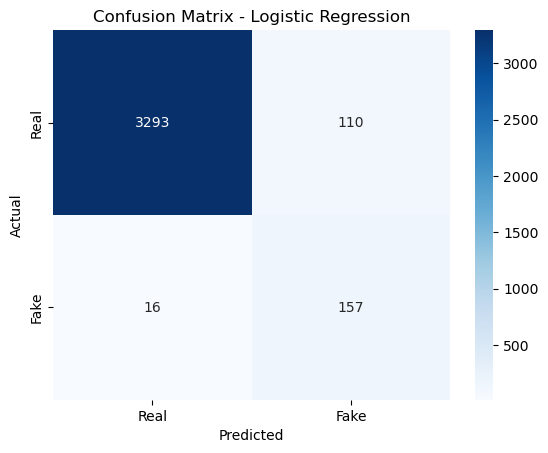

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [45]:
from sklearn.naive_bayes import MultinomialNB


nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       0.90      0.46      0.61       173

    accuracy                           0.97      3576
   macro avg       0.94      0.73      0.80      3576
weighted avg       0.97      0.97      0.97      3576



In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.56      0.72       173

    accuracy                           0.98      3576
   macro avg       0.98      0.78      0.85      3576
weighted avg       0.98      0.98      0.98      3576



In [47]:
from sklearn.metrics import f1_score, recall_score, precision_score

models = {'Logistic Regression': y_pred_log, 'Naive Bayes': y_pred_nb, 'Random Forest': y_pred_rf}

for name, preds in models.items():
    print(f"{name}:")
    print(f"  Precision: {precision_score(y_test, preds):.2f}")
    print(f"  Recall: {recall_score(y_test, preds):.2f}")
    print(f"  F1-score: {f1_score(y_test, preds):.2f}")
    print()

Logistic Regression:
  Precision: 0.59
  Recall: 0.91
  F1-score: 0.71

Naive Bayes:
  Precision: 0.90
  Recall: 0.46
  F1-score: 0.61

Random Forest:
  Precision: 0.99
  Recall: 0.56
  F1-score: 0.72



In [48]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[('lr', log_model), ('rf', rf_model)],
    voting='soft'  # averages predicted probabilities instead of hard yes/no votes
)
voting_model.fit(X_train, y_train)

y_pred_voting = voting_model.predict(X_test)
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.89      0.83      0.86       173

    accuracy                           0.99      3576
   macro avg       0.94      0.91      0.93      3576
weighted avg       0.99      0.99      0.99      3576



In [49]:
print(f"Voting Classifier:")
print(f"  Precision: {precision_score(y_test, y_pred_voting):.2f}")
print(f"  Recall: {recall_score(y_test, y_pred_voting):.2f}")
print(f"  F1-score: {f1_score(y_test, y_pred_voting):.2f}")

Voting Classifier:
  Precision: 0.89
  Recall: 0.83
  F1-score: 0.86


In [50]:
tfidf_names = tfidf.get_feature_names_out()
structured_names = ['telecommuting', 'has_company_logo', 'has_questions']
cat_names = encoder.get_feature_names_out(cat_cols)

feature_names = list(tfidf_names) + list(structured_names) + list(cat_names)
print(len(feature_names))
print(X_final.shape[1])

5201
5201


In [51]:
!pip install shap

In [52]:
import shap

explainer_lr = shap.LinearExplainer(log_model, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)

Background dataset has 14304 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=14304 when initializing the masker.


In [53]:
explainer_rf = shap.TreeExplainer(rf_model)
X_test_sample = X_test[:200].toarray().astype(float)
shap_values_rf = explainer_rf.shap_values(X_test_sample, check_additivity=False)

In [54]:
print(type(shap_values_rf))
print(len(shap_values_rf) if isinstance(shap_values_rf, list) else shap_values_rf.shape)

<class 'numpy.ndarray'>
(200, 5201, 2)


In [55]:
shap_values_rf_fake = shap_values_rf[:, :, 1]
print(shap_values_rf_fake.shape)

(200, 5201)


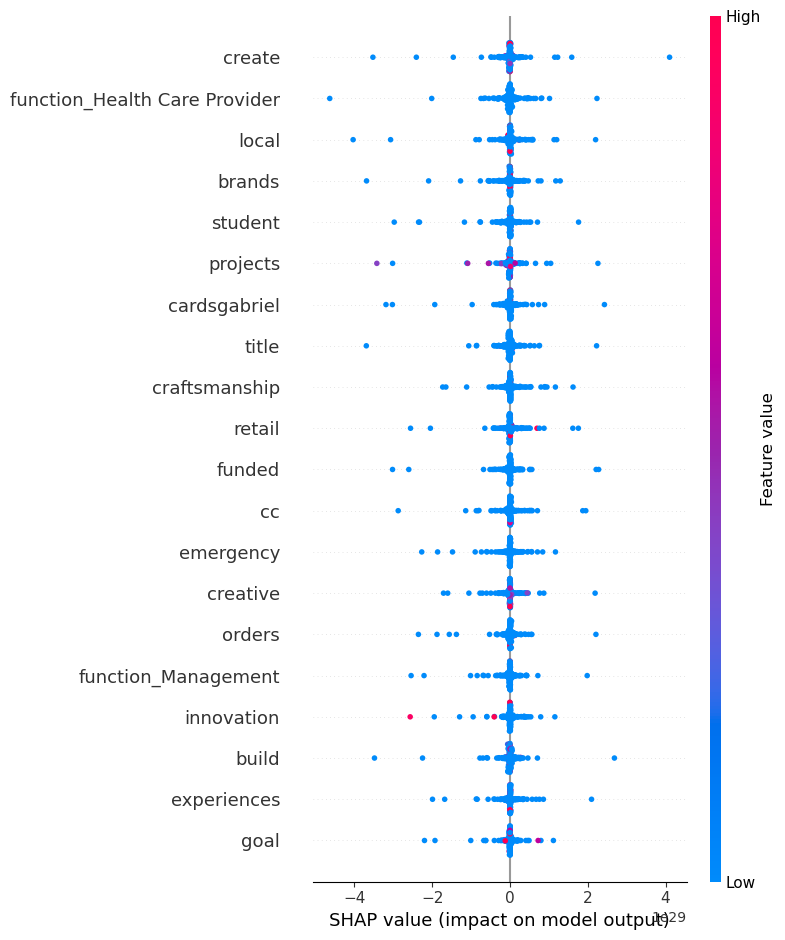

In [56]:
shap.summary_plot(shap_values_rf_fake, X_test_sample, feature_names=feature_names)

In [57]:
X_test_sample2 = X_test[:500].toarray().astype(float)
shap_values_rf2 = explainer_rf.shap_values(X_test_sample2, check_additivity=False)
shap_values_rf2_fake = shap_values_rf2[:, :, 1]

In [58]:
print(shap_values_rf2_fake.shape)

(500, 5201)


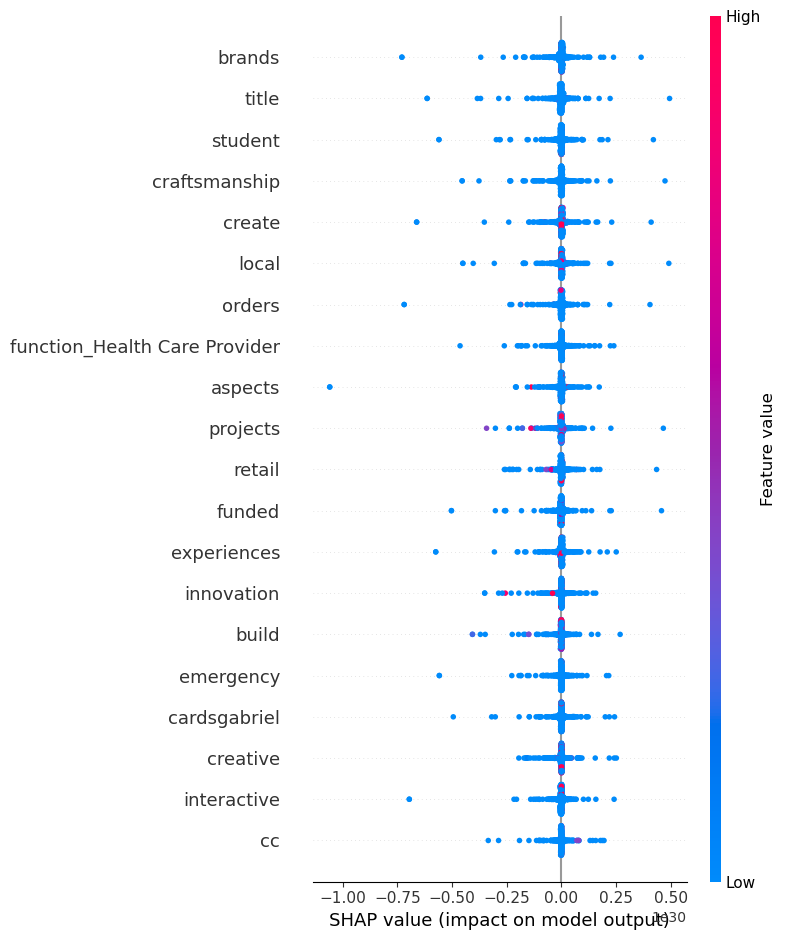

In [59]:
shap.summary_plot(shap_values_rf2_fake, X_test_sample2, feature_names=feature_names)

In [60]:
import pickle

with open('voting_model.pkl', 'wb') as f:
    pickle.dump(voting_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)


with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("All files saved successfully!")

All files saved successfully!


In [61]:
!pip install streamlit

In [62]:
print(X_text.shape)
print(y.shape)


(17880, 5000)
(17880,)


In [63]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train_text.shape, X_test_text.shape)

(14304, 5000) (3576, 5000)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

log_model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
rf_model_text = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

voting_model_text = VotingClassifier(
    estimators=[('lr', log_model_text), ('rf', rf_model_text)],
    voting='soft'
)
voting_model_text.fit(X_train_text, y_train_text)

print("Training complete!")

Training complete!


In [65]:
from sklearn.metrics import classification_report

y_pred_text = voting_model_text.predict(X_test_text)
print(classification_report(y_test_text, y_pred_text))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.92      0.76      0.83       173

    accuracy                           0.99      3576
   macro avg       0.95      0.88      0.91      3576
weighted avg       0.98      0.99      0.98      3576



In [66]:
from sklearn.metrics import classification_report

y_probs_text = voting_model_text.predict_proba(X_test_text)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    y_pred_adjusted = (y_probs_text >= threshold).astype(int)
    print(f"Threshold = {threshold}")
    print(classification_report(y_test_text, y_pred_adjusted))
    print("-" * 50)

Threshold = 0.5
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.92      0.76      0.83       173

    accuracy                           0.99      3576
   macro avg       0.95      0.88      0.91      3576
weighted avg       0.98      0.99      0.98      3576

--------------------------------------------------
Threshold = 0.4
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.80      0.84      0.82       173

    accuracy                           0.98      3576
   macro avg       0.89      0.91      0.90      3576
weighted avg       0.98      0.98      0.98      3576

--------------------------------------------------
Threshold = 0.35
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.73      0.90      0.80       173

    accuracy                   

In [67]:
print(voting_model_text)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     random_state=42))],
                 voting='soft')


In [68]:
import pickle

with open('voting_model_text.pkl', 'wb') as f:
    pickle.dump(voting_model_text, f)

print("Text-only model saved successfully!")

Text-only model saved successfully!


In [69]:
print(voting_model_text)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     random_state=42))],
                 voting='soft')


In [70]:
from sklearn.metrics import confusion_matrix

y_pred_035 = (y_probs_text >= 0.35).astype(int)
cm_exact = confusion_matrix(y_test_text, y_pred_035)
print(cm_exact)

[[3344   59]
 [  17  156]]
